In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import date, timedelta

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [34]:
df = pd.read_csv('../data/processed/clean_makeup.csv')

## Exploratory Data Analysis

In [35]:
df.shape

(931, 9)

In [36]:
df.head(10)

,id,brand,name,category,product_type,price,currency,tag_list,rating
0,1048,colourpop,Lippie Pencil,pencil,lip_liner,5.0,CAD,"['cruelty free', 'Vegan']",NaN
1,1047,colourpop,Blotted Lip,lipstick,lipstick,5.5,CAD,"['cruelty free', 'Vegan']",NaN
2,1046,colourpop,Lippie Stix,lipstick,lipstick,5.5,CAD,"['cruelty free', 'Vegan']",NaN
3,1045,colourpop,No Filter Foundation,liquid,foundation,12.0,CAD,"['cruelty free', 'Vegan']",NaN
4,1044,boosh,Lipstick,lipstick,lipstick,26.0,CAD,"['Chemical Free', 'Organic']",NaN
5,1043,deciem,Serum Foundation,liquid,foundation,6.7,CAD,"['water free', 'cruelty free', 'alcohol free',...",NaN
6,1042,deciem,Coverage Foundation,liquid,foundation,6.9,CAD,"['water free', 'cruelty free', 'alcohol free',...",NaN
7,1041,zorah biocosmetiques,Liquid Liner,liquid,eyeliner,0.0,USD,"['purpicks', 'EcoCert']",NaN
8,1040,zorah biocosmetiques,Eyeshadow,NaN,eyeshadow,0.0,USD,"['purpicks', 'EcoCert']",NaN
9,1039,w3llpeople,Realist Invisible Setting Powder,powder,foundation,0.0,USD,"['EWG Verified', 'purpicks', 'Gluten Free']",NaN


In [37]:
df.tail(10)

,id,brand,name,category,product_type,price,currency,tag_list,rating
921,10,l'oreal,L'Oreal Paris Voluminous Million Lashes Mascara,NaN,mascara,13.29,NaN,[],4.6
922,9,maybelline,Maybelline Great Lash Lots of Lashes Mascara,NaN,mascara,7.79,NaN,[],4.2
923,8,maybelline,Maybelline Lash Stiletto Ultimate Length Mascara,NaN,mascara,10.99,NaN,[],4.0
924,7,maybelline,Maybelline Volum'Express the Falsies Mascara,NaN,mascara,9.79,NaN,[],4.0
925,6,covergirl,CoverGirl Lashblast Volume Blasting Mascara,NaN,mascara,9.99,NaN,[],4.8
926,5,pacifica,Pacifica Stellar Gaze Length & Strength Minera...,NaN,mascara,28.00,NaN,"['Natural', 'Vegan']",4.2
927,4,physicians formula,Physicians Formula Organic Wear FakeOut Mascara,NaN,mascara,15.79,NaN,"['Natural', 'Gluten Free']",3.9
928,3,physicians formula,Physicians Formula Organic Wear Lash Boosting ...,NaN,mascara,15.79,NaN,"['Natural', 'Gluten Free']",3.7
929,2,NaN,L' Oreal Paris Voluminous Mascara,NaN,mascara,9.99,NaN,[],4.5
930,1,pure anada,Pure Anada Natural Mascara,NaN,mascara,14.00,NaN,"['Natural', 'Gluten Free', 'Canadian']",4.6


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         919 non-null    str    
 2   name          931 non-null    str    
 3   category      507 non-null    str    
 4   product_type  931 non-null    str    
 5   price         917 non-null    float64
 6   currency      368 non-null    str    
 7   tag_list      931 non-null    str    
 8   rating        340 non-null    float64
dtypes: float64(2), int64(1), str(6)
memory usage: 65.6 KB


In [39]:
df.isnull().sum()

id                0
brand            12
name              0
category        424
product_type      0
price            14
currency        563
tag_list          0
rating          591
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [51]:
df.describe(include='all')

# count = 931 , max = 1048 ?

,id,brand,name,category,product_type,price,currency,tag_list,rating
count,931.000000,919,931,507,931,917.000000,368,931,340.000000
unique,NaN,57,928,14,10,NaN,3,38,NaN
top,NaN,nyx,Lipstick,lipstick,foundation,NaN,USD,[],NaN
freq,NaN,164,2,122,166,NaN,287,732,NaN
mean,531.163265,NaN,NaN,NaN,NaN,16.508593,NaN,NaN,4.319118
std,311.054915,NaN,NaN,NaN,NaN,11.028035,NaN,NaN,0.675849
min,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.500000
25%,263.000000,NaN,NaN,NaN,NaN,8.990000,NaN,NaN,4.000000
50%,518.000000,NaN,NaN,NaN,NaN,13.990000,NaN,NaN,4.500000
75%,814.500000,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,5.000000


In [65]:
# checking for missing IDs

perfect_sequence = set(range(1049))

actual_ids = set(df['id'])

missing_ids = perfect_sequence - actual_ids
print(sorted(missing_ids))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [53]:
# changing 'id' column to a categorical
df['id'] = df['id'].astype(str)

### Distribution and Outliers

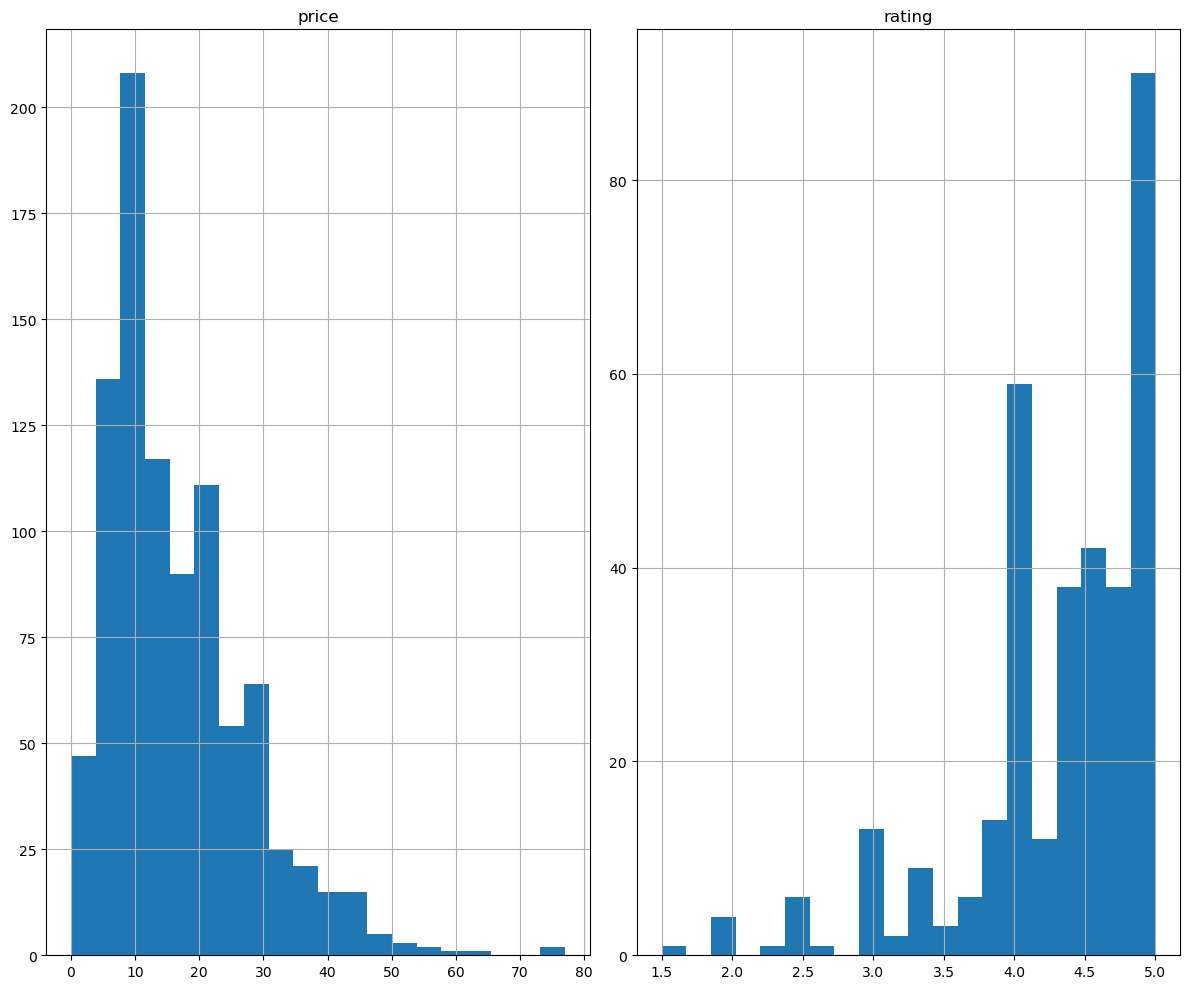

In [54]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

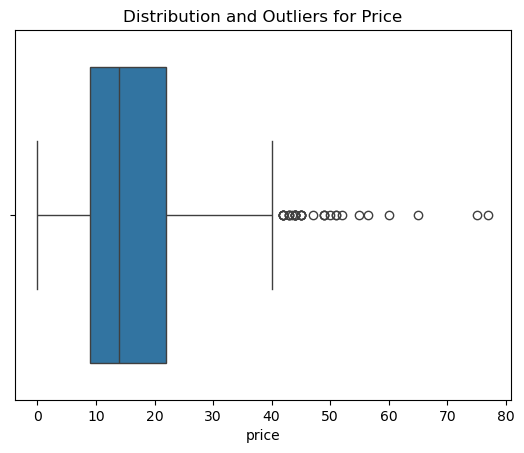

In [60]:
sns.boxplot(x=df['price'])
plt.title('Distribution and Outliers for Price')
plt.show()

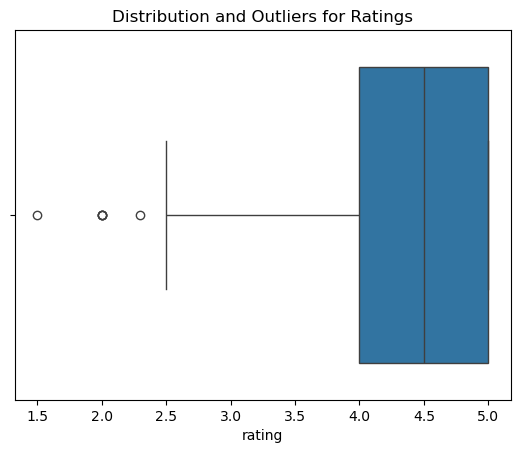

In [62]:
sns.boxplot(x=df['rating'])
plt.title('Distribution and Outliers for Ratings')
plt.show()